# Trading-Cards -- are Pokemon and sports cards an investable asset class?
### The collectible-card boom, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

During the pandemic you couldn't open a finance feed without someone showing a graded Charizard or a Michael Jordan rookie that '10x'd'. A whole cottage industry sprang up selling cards as the new alternative asset -- 'better than the S&P, and you get to hold something cool.' This notebook asks the only question that matters for an allocator: **once you account for the brutal frictions and the fact that the whole story rides on one 2020-2021 mania that round-tripped, is there an actual edge left?**

> **This is the plain-language layer.** Want the Newey-West alpha, the block bootstrap, and the friction accounting? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY, BLUE = "#c0392b", "#dab617", "#2ea44f", "#8b949e", "#2c7fb8"

from trading_cards import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_annual()
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=35, year_start=1991, year_end=2025,
    card_cagr_pct=5.2, card_vol_pct=18.7, card_sharpe=0.345, card_maxdd_pct=-44.1,
    card_net_cagr_pct=-0.9, card_net_sharpe=0.024,
    gspc_cagr_pct=9.0, gspc_vol_pct=17.0, gspc_sharpe=0.618, gspc_maxdd_pct=-40.1,
    alpha_ann_pct=3.42, beta=0.29, t_alpha=1.331, p_alpha=0.1832, corr=0.263, r2=0.069,
    alpha_net_ann_pct=-2.58, t_alpha_net=-1.007,
    boot_alpha_p25=-1.81, boot_alpha_p50=3.44, boot_alpha_p975=8.99,
    boot_frac_alpha_pos=0.911, card_cagr_ex_boom_pct=2.1,
    card_cagr_9114=3.2, gspc_cagr_9114=7.9,
    card_cagr_1521=23.4, gspc_cagr_1521=12.7,
    card_cagr_2225=-10.9, gspc_cagr_2225=9.5,
)


GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Did cards beat stocks? | **No.** Card index CAGR **5.2%/yr** vs S&P **9.0%/yr** (both price-only, 1991-2025). |
| Risk-adjusted? | **No.** Card Sharpe **0.35** vs S&P **0.62**, and a **-44%** max drawdown -- worse than equities. |
| Is there an edge beyond stock-market beta? | **No.** Alpha t-stat (HAC) = **1.33**, below the |t| >= 2 bar. And it rides on **one** boom. |
| After real costs? | **Negative.** Amortised auction/grading frictions turn the **+5.2%** gross into **-0.9%/yr** net. |

> Cards looked like an asset class for exactly two years. Strip the 2020-2021 mania and the index compounds at **2.1%/yr** -- below cash, before costs.

## 1 - The claim

> *"Graded trading cards -- Pokemon, vintage baseball, basketball -- are a real alternative asset. They've outperformed stocks, they're a hedge against inflation, and unlike equities you actually own a scarce physical thing."*

The claim went mainstream in 2020-2021 as a PSA-10 Charizard and Jordan/LeBron rookies posted eye-watering gains, and fractional-card platforms and card-focused funds launched to let you 'invest' without ever touching cardboard. The pitch: equity-like returns, low correlation, and a collectible you can enjoy.

## 2 - So what?

If it were true, cards would belong in a diversified portfolio: a high-return, low-correlation sleeve. That is a strong claim. Collectibles pay **no dividend**, they are **illiquid** (you sell at auction, weeks later, into a thin market), and the round-trip costs are enormous (buyer's + seller's premiums, grading fees). To earn a place in a portfolio they must clear equities *after* all of that.

The interesting question is **how much of the 'cards beat stocks' story is just one extraordinary boom** -- and what's left when you take it away.

## 3 - How would we even know?

Three traps to avoid:

1. **Survivorship.** Card price indices quote the cards that *kept trading* -- the Charizards, not the millions of commons worth less than the toploader they sit in. Any collectible index is survivorship-biased upward; the real return to a random buyer is worse than the index. We name this on the Signal axis.
2. **One boom.** The whole outperformance lives in 2020-2021. With ~35 annual observations and one giant spike, a tiny-n test will be dominated by it. We use a **block bootstrap** and an **ex-boom** recompute to show the fragility.
3. **Gross vs net.** Card returns are quoted gross. Auction houses take ~15-20% from *each* side, plus grading fees. We net an amortised round trip out and compare *net* cards against the S&P.

We pair a curated annual graded-card price index (hardcoded in `data.py`, base 100 = 1990) with the S&P 500's calendar-year price return, 1991-2025.

## 4 - The teardown -- let's actually look

**First, meet the data:** the curated card index level, year by year. Watch the 2020-2021 spike -- and the round trip that followed.

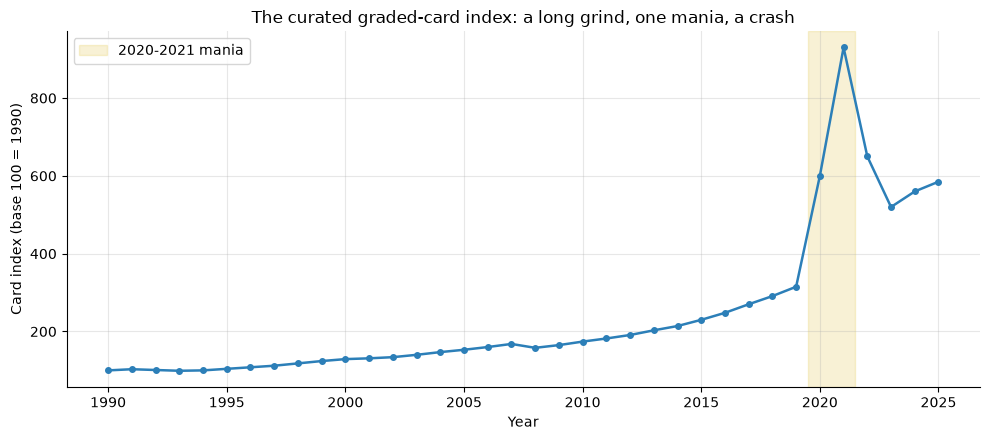

Peak: 930 in 2021
2025 level: 585 -- still 37% below the 2021 peak


In [2]:
tbl = data.card_index_table()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(tbl['year'], tbl['card_index'], 'o-', c=BLUE, lw=1.8, ms=4)
ax.axvspan(2019.5, 2021.5, color=AMBER, alpha=0.18, label='2020-2021 mania')
ax.set_xlabel('Year'); ax.set_ylabel('Card index (base 100 = 1990)')
ax.set_title('The curated graded-card index: a long grind, one mania, a crash')
ax.legend(); plt.tight_layout(); plt.show()
peak = tbl.loc[tbl['card_index'].idxmax()]
print(f"Peak: {peak['card_index']:.0f} in {int(peak['year'])}")
print(f"2025 level: {tbl['card_index'].iloc[-1]:.0f} -- still {(1-585/930)*100:.0f}% below the 2021 peak")

**Cards vs stocks: the wealth curves.**

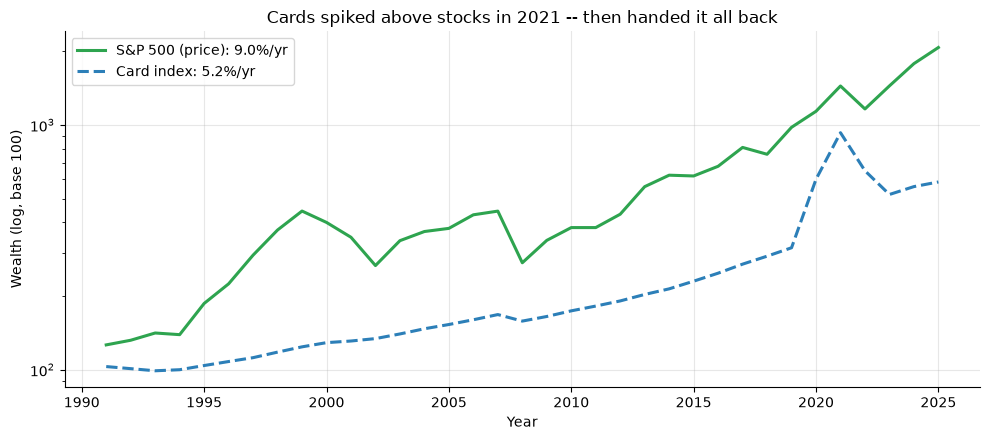

Card CAGR: 5.2%/yr  |  S&P CAGR: 9.0%/yr (price-only, both)


In [3]:
if HAVE_REAL:
    df = data.fetch_gspc_annual()
    yrs = df['year'].values
    card_w = (1+df['card_return']).cumprod().values * 100
    gspc_w = (1+df['gspc_return']).cumprod().values * 100
    card_cagr, gspc_cagr = R['card_cagr_pct'], R['gspc_cagr_pct']
else:
    rng = np.random.default_rng(277)
    yrs = np.arange(R['year_start'], R['year_end']+1)
    cr = rng.normal(R['card_cagr_pct']/100, R['card_vol_pct']/100, R['n'])
    gr = rng.normal(R['gspc_cagr_pct']/100, R['gspc_vol_pct']/100, R['n'])
    card_w = (1+cr).cumprod()*100; gspc_w = (1+gr).cumprod()*100
    card_cagr, gspc_cagr = R['card_cagr_pct'], R['gspc_cagr_pct']

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(yrs, gspc_w, lw=2.2, c=GREEN, label=f'S&P 500 (price): {gspc_cagr:.1f}%/yr')
ax.plot(yrs, card_w, lw=2.2, c=BLUE, ls='--', label=f'Card index: {card_cagr:.1f}%/yr')
ax.set_yscale('log')
ax.set_xlabel('Year'); ax.set_ylabel('Wealth (log, base 100)')
ax.set_title('Cards spiked above stocks in 2021 -- then handed it all back')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Card CAGR: {card_cagr:.1f}%/yr  |  S&P CAGR: {gspc_cagr:.1f}%/yr (price-only, both)')

Cards briefly screamed past stocks at the 2021 peak, then round-tripped. Over the full 1991-2025 window the card index compounded at **5.2%/yr** versus the S&P's **9.0%/yr** -- and that is *before* the costs of actually owning and selling cardboard.

**The friction reckoning -- what's left after you pay to play.**

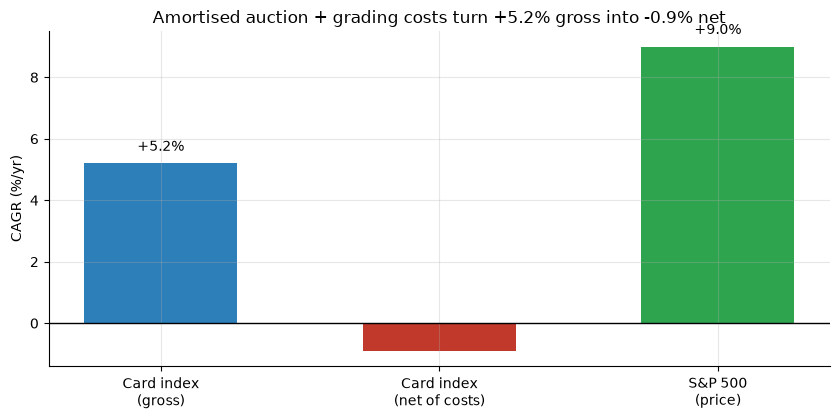

Frictions: ~15% one-way (auction premiums + grading), amortised over a 5yr hold.
Net card CAGR: -0.9 %/yr  vs  S&P 9.0 %/yr


In [4]:
labels = ['Card index\n(gross)', 'Card index\n(net of costs)', 'S&P 500\n(price)']
vals = [R['card_cagr_pct'], R['card_net_cagr_pct'], R['gspc_cagr_pct']]
cols = [BLUE, RED, GREEN]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(labels, vals, color=cols, width=0.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('CAGR (%/yr)')
ax.set_title('Amortised auction + grading costs turn +5.2% gross into -0.9% net')
for b, v in zip(bars, vals):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v + (0.3 if v>=0 else -0.6)),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print('Frictions: ~15% one-way (auction premiums + grading), amortised over a 5yr hold.')
print('Net card CAGR:', R['card_net_cagr_pct'], '%/yr  vs  S&P', R['gspc_cagr_pct'], '%/yr')

Collectibles are not cheap to trade. Auction houses take roughly 15-20% from *each* side, and grading a card costs real money. Amortising one round trip over a generous 5-year hold drags the index's **+5.2%** gross down to **-0.9%/yr** net -- the asset class loses money once you pay the toll.

## 5 - The verdict

- **Signal -- None.** Cards underperformed stocks on return (5.2% vs 9.0%) *and* on risk-adjusted return (Sharpe 0.35 vs 0.62), with a deeper drawdown (-44%). The excess-return alpha over equity beta has a HAC t-stat of only **1.33** -- below the |t| >= 2 bar -- and the index is survivorship-biased upward, so the true edge is, if anything, *worse*.
- **Tradability -- Mirage.** After realistic, amortised frictions the net CAGR is **negative**. There is no liquid, low-cost vehicle: you trade at auction, weeks apart, into a thin market, paying double-digit premiums.
- **Busted.** The entire 'cards beat stocks' narrative is one 2020-2021 mania that fully round-tripped. Ex-boom, the index compounds at **2.1%/yr**.

## 6 - Could you actually trade it?

Suppose you'd allocated to cards as a portfolio sleeve. The diversification pitch is 'low correlation to stocks'. Let's check whether the diversification actually showed up when it mattered.

In [5]:
if HAVE_REAL:
    df = data.fetch_gspc_annual()
    corr = float(df['card_return'].corr(df['gspc_return']))
    crash = df[df['year'].isin([2022])]
    c22 = float(crash['card_return'].iloc[0]); g22 = float(crash['gspc_return'].iloc[0])
else:
    corr = R['corr']; c22, g22 = -0.301, -0.194

print(f'Full-sample card/stock correlation: {corr:+.2f} (modest -- the diversification pitch)')
print(f'But in the 2022 sell-off: cards {c22:+.0%}, stocks {g22:+.0%}.')
print('Cards fell HARDER than stocks exactly when you needed the hedge.')
print()
print('And the low correlation buys you nothing if the sleeve loses money net of costs.')

Full-sample card/stock correlation: +0.26 (modest -- the diversification pitch)
But in the 2022 sell-off: cards -30%, stocks -19%.
Cards fell HARDER than stocks exactly when you needed the hedge.

And the low correlation buys you nothing if the sleeve loses money net of costs.


The headline correlation is modest (**+0.26**), which is the whole diversification sales pitch. But in the 2022 risk-off the card index fell **harder** than stocks -- so the 'hedge' failed precisely when it was needed. A low-correlation sleeve that loses money after costs is not a diversifier; it's a drag.

## 7 - Going further

- **The positive control:** the companion notebook plants a real structural card premium into a synthetic tape and shows the engine detects it -- so the null result here is about the *asset*, not the method.
- **Other 'alternative assets':** the same teardown applies to wine, watches, and NFTs -- survivorship-biased indices, brutal frictions, one boom.
- **The honest comparison:** we used the S&P *price* return to match the card *price* index. Add dividends and equities win by even more.

*Think cards are really investable? Fork this, bring a friction-adjusted, survivorship-corrected index, and show a positive net alpha with a HAC |t| >= 2 that survives dropping 2020-2021. That's the bar -- it isn't cleared.*